### 1. Import Libraries

Imports numpy, pandas, matplotlib, and seaborn. Scikit-learn pieces are imported later, right where each is first used.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load the Cleaned Dataset

Loads pk_student_employability_cleaned.csv, the dataset already cleaned in the Week 1 project, and checks its shape.

In [2]:
df = pd.read_csv('pk_student_employability_cleaned.csv')
df.shape

(47839, 49)

### 3. Preview the Data

Displays the first 5 rows to confirm the dataset loaded correctly.

In [3]:
df.head()

,student_id,age,gender,city,province,university_name,university_type,degree_program,specialization,current_semester,...,expected_salary_pkr,job_readiness_score,employability_status,preferred_career_path,likely_to_get_hired,remote_work_interest,daily_study_hours,internet_quality,device_type,social_media_usage_hours
0,PKSTU00001,21,Male,Lahore,Punjab,University of Peshawar,Public,Information Technology,Cloud IT,2,...,33000,100.0,Highly Employable,IT Manager,Yes,Neutral,3.8,Average,Smartphone Only,3.3
1,PKSTU00002,22,Female,Faisalabad,Punjab,COMSATS,Public,Information Technology,ERP Systems,3,...,76000,100.0,Highly Employable,Network Engineer,Yes,Slightly Interested,4.4,Average,Laptop,5.5
2,PKSTU00003,24,Female,Quetta,Balochistan,Air University,Public,Computer Science,Theory of Computation,3,...,50000,100.0,Highly Employable,Web Developer,Yes,Interested,7.5,Poor,Desktop,3.0
3,PKSTU00005,19,Female,Sargodha,Punjab,COMSATS,Public,Artificial Intelligence,Computer Vision,7,...,81000,88.8,Highly Employable,AI/ML Engineer,Yes,Interested,5.5,Excellent,Laptop,2.9
4,PKSTU00006,19,Male,Gilgit,GB,Hamdard University,Private,Artificial Intelligence,Deep Learning,4,...,100000,99.4,Highly Employable,AI/ML Engineer,Yes,Neutral,7.4,Poor,Laptop,6.9


### 4. Inspect the Target Column

Shows the count and percentage split of likely_to_get_hired, confirming the roughly 96% Yes / 4% No class imbalance.

In [4]:
df['likely_to_get_hired'].value_counts()
df['likely_to_get_hired'].value_counts(normalize=True) * 100

likely_to_get_hired
Yes    96.212295
No      3.787705
Name: proportion, dtype: float64

### 5. Create a Numeric Target Column

Converts likely_to_get_hired into a numeric target column, 1 for Yes and 0 for No, since scikit-learn models require numeric labels.

In [5]:
df['target'] = (df['likely_to_get_hired'] == 'Yes').astype(int)
df['target'].value_counts()

target
1    46027
0     1812
Name: count, dtype: int64

### 6. Select Feature Columns (X) and Target (y)

Drops student_id (identifier), likely_to_get_hired and target (the label itself), employability_status, and job_readiness_score (both leakage risks, since they are strongly related to the target) to build the feature set X, and isolates the target as y.

In [6]:
drop_cols = ['student_id', 'likely_to_get_hired', 'employability_status', 'job_readiness_score', 'target']
X = df.drop(columns=drop_cols)
y = df['target']

X.shape

(47839, 45)

### 7. Check Target Shape

Confirms y has one value per row, matching X.

In [7]:
y.shape

(47839,)

### 8. Encode Categorical Features

Converts all remaining text/category columns in X into numeric columns using one-hot encoding, since models require numeric input.

In [8]:
X = pd.get_dummies(X, drop_first=True)
X.shape

(47839, 238)

### 9. Preview Encoded Features

Displays the first rows of the encoded feature set to confirm the conversion worked as expected.

In [9]:
X.head()

,age,current_semester,cgpa,attendance_percentage,number_of_internships,monthly_freelancing_income_pkr,certifications_count,hackathon_participation,expected_salary_pkr,daily_study_hours,...,remote_work_interest_Very Interested,internet_quality_Excellent,internet_quality_Good,internet_quality_Poor,internet_quality_Very Poor,device_type_Laptop,device_type_Laptop+Desktop,device_type_Laptop+Smartphone,device_type_Laptop+Tablet,device_type_Smartphone Only
0,21,2,2.64,79.6,1,49975.0,2.0,0,33000,3.8,...,False,False,False,False,False,False,False,False,False,True
1,22,3,1.82,66.6,1,0.0,4.0,0,76000,4.4,...,False,False,False,False,False,True,False,False,False,False
2,24,3,3.62,78.5,1,20602.0,1.0,0,50000,7.5,...,False,False,False,True,False,False,False,False,False,False
3,19,7,3.24,67.1,1,0.0,1.0,0,81000,5.5,...,False,True,False,False,False,True,False,False,False,False
4,19,4,3.02,99.1,0,24966.0,1.0,1,100000,7.4,...,False,False,False,True,False,True,False,False,False,False


### 10. Import Train/Test Split Tool

Imports train_test_split from scikit-learn, used to divide the data into training and testing portions.

In [10]:
from sklearn.model_selection import train_test_split

### 11. Split Data into Training and Testing Sets

Splits X and y into 80% training and 20% testing data, using stratify=y to preserve the same class imbalance ratio in both sets, and a fixed random_state for reproducibility.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape

(38271, 238)

### 12. Check Test Set Shape

Confirms the size of the held-out testing set.

In [12]:
X_test.shape

(9568, 238)

### 13. Import Logistic Regression

Imports the LogisticRegression model class from scikit-learn.

In [13]:
from sklearn.linear_model import LogisticRegression

### 14. Train a Logistic Regression Model

Builds a pipeline that first scales the features with StandardScaler, then trains a LogisticRegression model on the training data. Scaling helps logistic regression converge properly and treat all features fairly regardless of their original numeric ranges.

In [14]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# This scales your data automatically before training
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

### 15. Generate Predictions

Uses the trained model to predict outcomes on the unseen testing set.

In [15]:
predictions = model.predict(X_test)

### 16. Evaluate the Model (Yes Class)

Calculates accuracy, precision, recall, and F1-score comparing the model's predictions to the true test labels, using the default positive class (Yes).

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

Accuracy:  0.9715
Precision: 0.9785
Recall:    0.9922
F1-score:  0.9853


### 17. Evaluate the Model (No Class)

Recalculates precision, recall, and F1-score treating No as the positive class instead, since correctly catching the rare No cases is arguably the more useful and harder task given the class imbalance.

In [17]:
precision_no = precision_score(y_test, predictions, pos_label=0)
recall_no = recall_score(y_test, predictions, pos_label=0)
f1_no = f1_score(y_test, predictions, pos_label=0)

print(f"Precision (No): {precision_no:.4f}")
print(f"Recall (No):    {recall_no:.4f}")
print(f"F1-score (No):  {f1_no:.4f}")


Precision (No): 0.6910
Recall (No):    0.4448
F1-score (No):  0.5412


### 18. Confusion Matrix

Visualizes the four outcomes (correct/incorrect predictions for each class) as a heatmap, making the effect of the class imbalance visible directly.

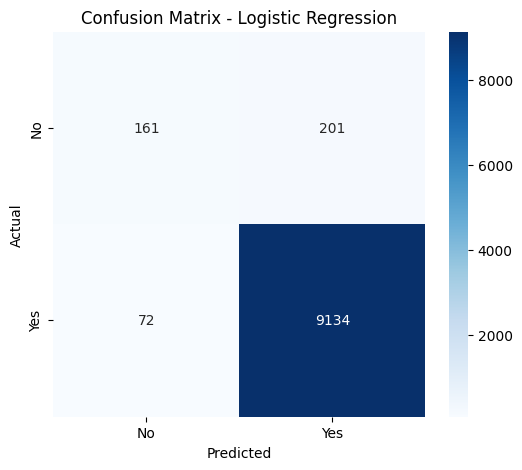

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### 19. Train and Evaluate a Decision Tree Model

Trains a second model, DecisionTreeClassifier, on the same training data, generates predictions, and calculates the same four metrics for comparison against Logistic Regression.

In [19]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

tree_predictions = tree_model.predict(X_test)

tree_accuracy = accuracy_score(y_test, tree_predictions)
tree_precision = precision_score(y_test, tree_predictions)
tree_recall = recall_score(y_test, tree_predictions)
tree_f1 = f1_score(y_test, tree_predictions)

print(f"Accuracy:  {tree_accuracy:.4f}")
print(f"Precision: {tree_precision:.4f}")
print(f"Recall:    {tree_recall:.4f}")
print(f"F1-score:  {tree_f1:.4f}")


Accuracy:  0.9457
Precision: 0.9735
Recall:    0.9699
F1-score:  0.9717


### 20. Compare Both Models

Builds a single table comparing Logistic Regression and Decision Tree across all four metrics, for direct side-by-side comparison.

In [20]:
comparison = pd.DataFrame({
    'Logistic Regression': [accuracy, precision, recall, f1],
    'Decision Tree': [tree_accuracy, tree_precision, tree_recall, tree_f1]
}, index=['Accuracy', 'Precision', 'Recall', 'F1-score'])

comparison.round(4)

,Logistic Regression,Decision Tree
Accuracy,0.9715,0.9457
Precision,0.9785,0.9735
Recall,0.9922,0.9699
F1-score,0.9853,0.9717


## Interpretation

Accuracy alone looks strong for both models (well above 90%), but that is
expected given the roughly 96% Yes / 4% No class split in this dataset, not
necessarily a sign of a genuinely strong model. Looking at precision, recall,
and F1-score for the No class specifically (rather than the default Yes class)
gives a more honest picture: it shows how well each model actually catches the
rare, harder-to-predict students who are not likely to get hired, which is
arguably the more useful group to identify correctly in a real career-support
tool. The comparison table above shows whether Logistic Regression or the
Decision Tree handles this imbalance better.

**Limitations:** with such a skewed class distribution, both models have far
fewer No examples to learn from than Yes examples, which naturally limits how
well they can generalize on that minority class.

**Next steps to try:** using `class_weight='balanced'` on either model to
penalize missing the minority class more heavily, gathering more No-labeled
examples if possible, or trying resampling techniques (oversampling the minority
class or undersampling the majority class) before training.
